In [1]:
# Cell 0 — Setup
!pip install -q kagglehub timm
from google.colab import drive
from pathlib import Path
import json, os, random, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image
import timm
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                             accuracy_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
KOA_ROOT = Path('/content/drive/MyDrive/KOA')
NB3_OUT = KOA_ROOT / 'NB3'
NB3_OUT.mkdir(parents=True, exist_ok=True)
SAVE_DIR = KOA_ROOT / 'saved_models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

import kagglehub
kaggle_path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")

def find_split_root(base):
    base = Path(base)
    for p in [base] + list(base.rglob('*')):
        if p.is_dir() and (p / 'train').is_dir():
            return p
    return base

kaggle_root = find_split_root(kaggle_path)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Mounted at /content/drive
Using Colab cache for faster access to the 'knee-osteoarthritis-dataset-with-severity' dataset.
Device: cuda


In [2]:
# Cell 1 — Constants + Infrastructure
SEEDS = [42, 123, 456]
BATCH_SIZE = 16
EPOCHS = 20
PATIENCE = 4
LR = 1e-4
IMG_SIZE = 224

ARCHITECTURES = {
    'ConvNeXt-L': 'convnext_large',
    'EfficientNet-B0': 'efficientnet_b0',
    'DenseNet201': 'densenet201',
    'Xception': 'xception',
    'Swin-T': 'swin_tiny_patch4_window7_224',
}

BINARY_TASKS = {
    'Screening': 1,
    'OA': 2,
    'Severe': 3,
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class KneeDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(row.path).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0,0,0))
        return self.transform(img), int(row.label)

In [3]:
# Cell 2 — Load Data + Create Binary Splits
records = []
for split in ['train', 'val', 'test']:
    split_dir = kaggle_root / split
    if not split_dir.exists():
        continue
    for grade_dir in sorted(split_dir.iterdir()):
        if not grade_dir.is_dir():
            continue
        try:
            grade = int(grade_dir.name)
        except ValueError:
            continue
        for img_path in sorted(grade_dir.glob('*')):
            if img_path.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                records.append({'path': str(img_path), 'grade': grade, 'split': split})

df = pd.DataFrame(records)

task_dfs = {}
task_weights = {}
for task_name, threshold in BINARY_TASKS.items():
    t_df = df.copy()
    t_df['label'] = (t_df['grade'] >= threshold).astype(int)
    task_dfs[task_name] = t_df

    train_labels = t_df[t_df['split'] == 'train']['label'].values
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
    task_weights[task_name] = torch.tensor(cw, dtype=torch.float).to(device)

    pos_rate = train_labels.mean()
    print(f"{task_name} (KL≥{threshold}): {len(t_df[t_df['split']=='train'])} train, "
          f"pos_rate={pos_rate:.3f}, weights={cw.round(3)}")

Screening (KL≥1): 5778 train, pos_rate=0.604, weights=[1.264 0.827]
OA (KL≥2): 5778 train, pos_rate=0.423, weights=[0.867 1.181]
Severe (KL≥3): 5778 train, pos_rate=0.161, weights=[0.596 3.106]


In [4]:
# Cell 3 — Training Functions
def train_binary_model(model, train_loader, val_loader, criterion,
                       epochs=EPOCHS, patience=PATIENCE, lr=LR):
    head_kw = ['classifier', 'head', 'fc']
    head_params = [p for n, p in model.named_parameters() if any(k in n for k in head_kw)]
    backbone_params = [p for n, p in model.named_parameters() if not any(k in n for k in head_kw)]

    if head_params:
        param_groups = [{'params': backbone_params, 'lr': lr * 0.1},
                        {'params': head_params, 'lr': lr}]
    else:
        param_groups = [{'params': model.parameters(), 'lr': lr}]

    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)
    scaler = torch.amp.GradScaler('cuda')
    best_val_loss = float('inf')
    counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                out = model(x)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * x.size(0)
            correct += (torch.argmax(out, dim=1) == y).sum().item()
            total += y.size(0)
        scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                with torch.amp.autocast('cuda'):
                    out = model(x)
                    loss = criterion(out, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (torch.argmax(out, dim=1) == y).sum().item()
                val_total += y.size(0)

        val_loss_avg = val_loss / val_total
        print(f"  Epoch {epoch}/{epochs}  train_acc={correct/total:.4f}  "
              f"val_acc={val_correct/val_total:.4f}  val_loss={val_loss_avg:.4f}")

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch}")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model

def evaluate_binary(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.amp.autocast('cuda'):
                out = model(x)
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(out, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs)
    preds, labels, probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)
    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0
    sens = np.sum((preds == 1) & (labels == 1)) / max(np.sum(labels == 1), 1)
    spec = np.sum((preds == 0) & (labels == 0)) / max(np.sum(labels == 0), 1)
    return acc, auc, sens, spec, preds, labels, probs

In [5]:
# Cell 4 — Run 45 Binary Experiments
results = {}
for arch_name, model_name in ARCHITECTURES.items():
    results[arch_name] = {}
    for task_name, threshold in BINARY_TASKS.items():
        results[arch_name][task_name] = {'acc': [], 'auc': [], 'sens': [], 'spec': [],
                                          'probs': [], 'labels': []}
        print(f"\n{'='*60}")
        print(f"{arch_name} — {task_name} (KL≥{threshold})")
        print(f"{'='*60}")

        t_df = task_dfs[task_name]
        train_loader = DataLoader(KneeDataset(t_df[t_df['split']=='train'], train_transform),
                                  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(KneeDataset(t_df[t_df['split']=='val'], val_transform),
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        test_loader = DataLoader(KneeDataset(t_df[t_df['split']=='test'], val_transform),
                                 batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

        for seed in SEEDS:
            save_path = str(SAVE_DIR / f"{arch_name}_{task_name}_seed{seed}.pth")

            if os.path.exists(save_path):
                print(f"  ✓ Loading {arch_name}_{task_name}_seed{seed}")
                model = timm.create_model(model_name, pretrained=False, num_classes=2).to(device)
                model.load_state_dict(torch.load(save_path, map_location=device))
            else:
                print(f"  Training {arch_name}_{task_name}_seed{seed}...")
                set_seed(seed)
                model = timm.create_model(model_name, pretrained=True, num_classes=2).to(device)
                criterion = nn.CrossEntropyLoss(weight=task_weights[task_name])
                model = train_binary_model(model, train_loader, val_loader, criterion)
                torch.save(model.state_dict(), save_path)
                print(f"  💾 Saved")

            acc, auc, sens, spec, preds, labels, probs = evaluate_binary(model, test_loader)
            results[arch_name][task_name]['acc'].append(acc)
            results[arch_name][task_name]['auc'].append(auc)
            results[arch_name][task_name]['sens'].append(sens)
            results[arch_name][task_name]['spec'].append(spec)
            results[arch_name][task_name]['probs'].append(probs.tolist())
            results[arch_name][task_name]['labels'].append(labels.tolist())
            print(f"    acc={acc:.4f}  auc={auc:.4f}  sens={sens:.4f}  spec={spec:.4f}")

            del model
            torch.cuda.empty_cache()
            gc.collect()

print("\n✓ All 45 binary runs complete")


ConvNeXt-L — Screening (KL≥1)
  Training ConvNeXt-L_Screening_seed42...


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.7089  val_acc=0.7942  val_loss=0.4540
  Epoch 2/20  train_acc=0.8051  val_acc=0.7930  val_loss=0.4267
  Epoch 3/20  train_acc=0.8268  val_acc=0.8172  val_loss=0.3933
  Epoch 4/20  train_acc=0.8519  val_acc=0.8136  val_loss=0.4372
  Epoch 5/20  train_acc=0.8766  val_acc=0.8136  val_loss=0.4774
  Epoch 6/20  train_acc=0.8475  val_acc=0.7966  val_loss=0.4465
  Epoch 7/20  train_acc=0.8624  val_acc=0.8087  val_loss=0.4187
  Early stopping at epoch 7
  💾 Saved
    acc=0.8364  auc=0.9231  sens=0.7896  spec=0.9108
  Training ConvNeXt-L_Screening_seed123...
  Epoch 1/20  train_acc=0.7241  val_acc=0.7893  val_loss=0.4150
  Epoch 2/20  train_acc=0.8055  val_acc=0.8051  val_loss=0.3940
  Epoch 3/20  train_acc=0.8311  val_acc=0.8196  val_loss=0.3887
  Epoch 4/20  train_acc=0.8548  val_acc=0.8123  val_loss=0.4154
  Epoch 5/20  train_acc=0.8783  val_acc=0.8027  val_loss=0.4332
  Epoch 6/20  train_acc=0.8460  val_acc=0.8015  val_loss=0.4271
  Epoch 7/20  train_acc=0.8543  va

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.5942  val_acc=0.5884  val_loss=1.3865
  Epoch 2/20  train_acc=0.6404  val_acc=0.6211  val_loss=1.1948
  Epoch 3/20  train_acc=0.6481  val_acc=0.6332  val_loss=1.0896
  Epoch 4/20  train_acc=0.6687  val_acc=0.6308  val_loss=1.1191
  Epoch 5/20  train_acc=0.6822  val_acc=0.6429  val_loss=1.0524
  Epoch 6/20  train_acc=0.6668  val_acc=0.6356  val_loss=1.1254
  Epoch 7/20  train_acc=0.6935  val_acc=0.6634  val_loss=1.1074
  Epoch 8/20  train_acc=0.7013  val_acc=0.6429  val_loss=1.2740
  Epoch 9/20  train_acc=0.7032  val_acc=0.6562  val_loss=1.0842
  Early stopping at epoch 9
  💾 Saved
    acc=0.6733  auc=0.7360  sens=0.6519  spec=0.7074
  Training EfficientNet-B0_Screening_seed123...
  Epoch 1/20  train_acc=0.5950  val_acc=0.5726  val_loss=1.3900
  Epoch 2/20  train_acc=0.6383  val_acc=0.6041  val_loss=1.3128
  Epoch 3/20  train_acc=0.6606  val_acc=0.6308  val_loss=1.1609
  Epoch 4/20  train_acc=0.6736  val_acc=0.6356  val_loss=1.1801
  Epoch 5/20  train_acc=0.672

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.6608  val_acc=0.6961  val_loss=0.5668
  Epoch 2/20  train_acc=0.7243  val_acc=0.7252  val_loss=0.5308
  Epoch 3/20  train_acc=0.7530  val_acc=0.7361  val_loss=0.5137
  Epoch 4/20  train_acc=0.7655  val_acc=0.6852  val_loss=0.5930
  Epoch 5/20  train_acc=0.7760  val_acc=0.7482  val_loss=0.4988
  Epoch 6/20  train_acc=0.7721  val_acc=0.7421  val_loss=0.5026
  Epoch 7/20  train_acc=0.7811  val_acc=0.7567  val_loss=0.5047
  Epoch 8/20  train_acc=0.7998  val_acc=0.7337  val_loss=0.5436
  Epoch 9/20  train_acc=0.8105  val_acc=0.7433  val_loss=0.5019
  Early stopping at epoch 9
  💾 Saved
    acc=0.7826  auc=0.8658  sens=0.7591  spec=0.8200
  Training DenseNet201_Screening_seed123...
  Epoch 1/20  train_acc=0.6520  val_acc=0.6780  val_loss=0.6051
  Epoch 2/20  train_acc=0.7288  val_acc=0.7191  val_loss=0.5519
  Epoch 3/20  train_acc=0.7503  val_acc=0.7034  val_loss=0.5545
  Epoch 4/20  train_acc=0.7589  val_acc=0.7203  val_loss=0.5514
  Epoch 5/20  train_acc=0.7764  v

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Epoch 1/20  train_acc=0.6411  val_acc=0.7518  val_loss=0.5263
  Epoch 2/20  train_acc=0.7385  val_acc=0.7433  val_loss=0.4892
  Epoch 3/20  train_acc=0.7745  val_acc=0.6477  val_loss=0.6874
  Epoch 4/20  train_acc=0.7944  val_acc=0.7748  val_loss=0.4394
  Epoch 5/20  train_acc=0.8094  val_acc=0.7833  val_loss=0.4319
  Epoch 6/20  train_acc=0.7736  val_acc=0.7772  val_loss=0.4374
  Epoch 7/20  train_acc=0.7899  val_acc=0.7373  val_loss=0.5212
  Epoch 8/20  train_acc=0.7911  val_acc=0.7131  val_loss=0.5685
  Epoch 9/20  train_acc=0.8001  val_acc=0.7833  val_loss=0.4397
  Early stopping at epoch 9
  💾 Saved
    acc=0.8188  auc=0.9042  sens=0.7935  spec=0.8592
  Training Swin-T_Screening_seed123...
  Epoch 1/20  train_acc=0.6539  val_acc=0.7349  val_loss=0.5428
  Epoch 2/20  train_acc=0.7501  val_acc=0.7603  val_loss=0.4979
  Epoch 3/20  train_acc=0.7771  val_acc=0.7639  val_loss=0.4777
  Epoch 4/20  train_acc=0.7994  val_acc=0.7785  val_loss=0.4440
  Epoch 5/20  train_acc=0.8018  val_ac

  Epoch 1/20  train_acc=0.6184  val_acc=0.5642  val_loss=0.6909
  Epoch 2/20  train_acc=0.7241  val_acc=0.7639  val_loss=0.4579
  Epoch 3/20  train_acc=0.7729  val_acc=0.7409  val_loss=0.4693
  Epoch 4/20  train_acc=0.7868  val_acc=0.7785  val_loss=0.4387
  Epoch 5/20  train_acc=0.8015  val_acc=0.7676  val_loss=0.4659
  Epoch 6/20  train_acc=0.7831  val_acc=0.7712  val_loss=0.4528
  Epoch 7/20  train_acc=0.7892  val_acc=0.7663  val_loss=0.4851
  Epoch 8/20  train_acc=0.7977  val_acc=0.7809  val_loss=0.4304
  Epoch 9/20  train_acc=0.8048  val_acc=0.7603  val_loss=0.4927
  Epoch 10/20  train_acc=0.8093  val_acc=0.7821  val_loss=0.4217
  Epoch 11/20  train_acc=0.8202  val_acc=0.7869  val_loss=0.4250
  Epoch 12/20  train_acc=0.8273  val_acc=0.7809  val_loss=0.4763
  Epoch 13/20  train_acc=0.8347  val_acc=0.7676  val_loss=0.5105
  Epoch 14/20  train_acc=0.8377  val_acc=0.7845  val_loss=0.4474
  Early stopping at epoch 14
  💾 Saved
    acc=0.8219  auc=0.9133  sens=0.7856  spec=0.8795

Swin-T

In [6]:
# Cell 5 — Results Table
from scipy import stats

def ci95(vals):
    n = len(vals)
    if n < 3:
        return np.mean(vals), np.mean(vals)
    se = np.std(vals, ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf(0.975, n - 1)
    m = np.mean(vals)
    return m - h, m + h

rows = []
for arch in ARCHITECTURES:
    for task in BINARY_TASKS:
        d = results[arch][task]
        m_acc = np.mean(d['acc'])
        m_auc = np.mean(d['auc'])
        ci_acc = ci95(d['acc'])
        ci_auc = ci95(d['auc'])
        rows.append({
            'Architecture': arch, 'Task': f"{task} (KL≥{BINARY_TASKS[task]})",
            'Accuracy': f"{m_acc:.3f}±{np.std(d['acc']):.3f}",
            'CI Acc': f"[{ci_acc[0]:.3f},{ci_acc[1]:.3f}]",
            'AUC': f"{m_auc:.3f}±{np.std(d['auc']):.3f}",
            'CI AUC': f"[{ci_auc[0]:.3f},{ci_auc[1]:.3f}]",
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))
df_results.to_csv(str(NB3_OUT / 'nb3_results_binary.csv'), index=False)
print("\n✓ nb3_results_binary.csv")

   Architecture             Task    Accuracy        CI Acc         AUC        CI AUC
     ConvNeXt-L Screening (KL≥1) 0.842±0.005 [0.826,0.858] 0.926±0.002 [0.919,0.934]
     ConvNeXt-L        OA (KL≥2) 0.878±0.002 [0.872,0.883] 0.952±0.000 [0.951,0.952]
     ConvNeXt-L    Severe (KL≥3) 0.961±0.005 [0.947,0.975] 0.990±0.000 [0.989,0.991]
EfficientNet-B0 Screening (KL≥1) 0.697±0.020 [0.636,0.758] 0.767±0.027 [0.685,0.849]
EfficientNet-B0        OA (KL≥2) 0.761±0.011 [0.728,0.795] 0.830±0.014 [0.787,0.874]
EfficientNet-B0    Severe (KL≥3) 0.888±0.003 [0.880,0.897] 0.922±0.008 [0.897,0.947]
    DenseNet201 Screening (KL≥1) 0.787±0.004 [0.775,0.800] 0.875±0.006 [0.855,0.894]
    DenseNet201        OA (KL≥2) 0.835±0.002 [0.829,0.840] 0.915±0.003 [0.905,0.924]
    DenseNet201    Severe (KL≥3) 0.943±0.008 [0.919,0.967] 0.974±0.004 [0.962,0.987]
       Xception Screening (KL≥1) 0.774±0.005 [0.759,0.789] 0.864±0.003 [0.853,0.874]
       Xception        OA (KL≥2) 0.812±0.006 [0.795,0.830] 0.893±

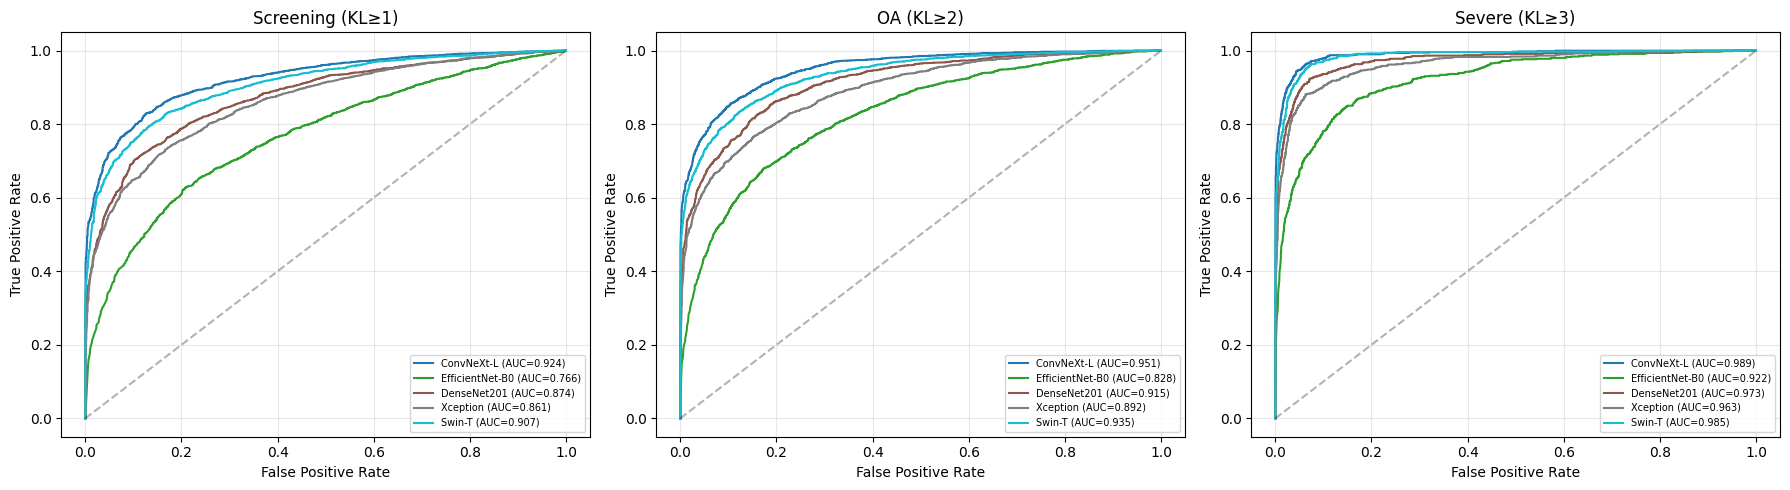

✓ nb3_roc_curves.png


In [7]:
# Cell 6 — ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(ARCHITECTURES)))

for t_idx, (task_name, threshold) in enumerate(BINARY_TASKS.items()):
    ax = axes[t_idx]
    for a_idx, arch in enumerate(ARCHITECTURES):
        all_probs = np.concatenate(results[arch][task_name]['probs'])
        all_labels = np.concatenate(results[arch][task_name]['labels'])
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        auc_val = roc_auc_score(all_labels, all_probs)
        ax.plot(fpr, tpr, color=colors[a_idx], label=f"{arch} (AUC={auc_val:.3f})")

    ax.plot([0,1], [0,1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{task_name} (KL≥{threshold})')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(NB3_OUT / 'nb3_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb3_roc_curves.png")

Utility Function — ConvNeXt-L Screening (KL≥1)
FN:FP Ratio Threshold Sensitivity Specificity
        1:1      0.37      0.8699      0.8216
        3:1      0.25      0.9128      0.7141
        5:1      0.15      0.9512      0.5535
       10:1      0.08      0.9849      0.3172
       20:1      0.06      0.9918      0.2102

Threshold shift (1:1 → 10:1): 29pp


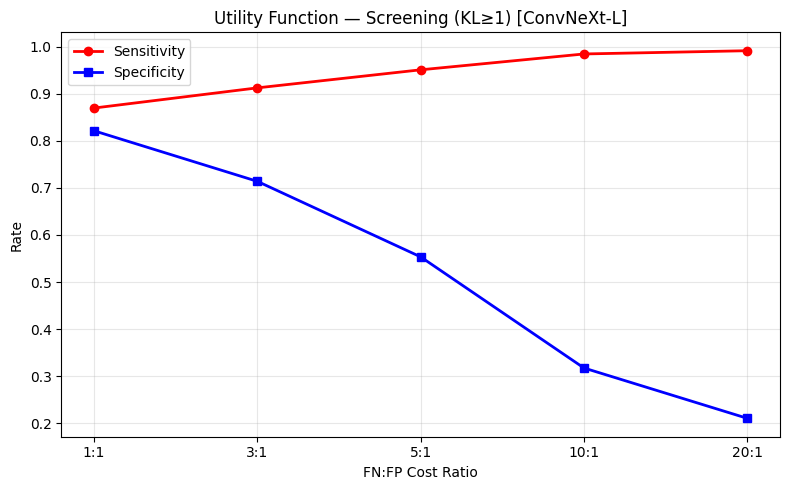

✓ nb3_utility.png


In [8]:
# Cell 7 — Utility Function (Screening Task KL≥1)
best_arch_screen = max(ARCHITECTURES, key=lambda a: np.mean(results[a]['Screening']['auc']))
all_probs = np.concatenate(results[best_arch_screen]['Screening']['probs'])
all_labels = np.concatenate(results[best_arch_screen]['Screening']['labels'])

ratios = [1, 3, 5, 10, 20]
rows = []
for r in ratios:
    best_thresh, best_util = 0.5, -1e9
    for t in np.arange(0.01, 1.0, 0.01):
        preds = (all_probs >= t).astype(int)
        tp = np.sum((preds == 1) & (all_labels == 1))
        tn = np.sum((preds == 0) & (all_labels == 0))
        fp = np.sum((preds == 1) & (all_labels == 0))
        fn = np.sum((preds == 0) & (all_labels == 1))
        util = tp + tn - fp - r * fn
        if util > best_util:
            best_util = util
            best_thresh = t
    preds = (all_probs >= best_thresh).astype(int)
    sens = np.sum((preds == 1) & (all_labels == 1)) / max(np.sum(all_labels == 1), 1)
    spec = np.sum((preds == 0) & (all_labels == 0)) / max(np.sum(all_labels == 0), 1)
    rows.append({'FN:FP Ratio': f"{r}:1", 'Threshold': f"{best_thresh:.2f}",
                 'Sensitivity': f"{sens:.4f}", 'Specificity': f"{spec:.4f}"})

df_util = pd.DataFrame(rows)
print(f"Utility Function — {best_arch_screen} Screening (KL≥1)")
print(df_util.to_string(index=False))

t_1_1 = float(rows[0]['Threshold'])
t_10_1 = float(rows[3]['Threshold'])
shift = abs(t_1_1 - t_10_1) * 100
print(f"\nThreshold shift (1:1 → 10:1): {shift:.0f}pp")

fig, ax = plt.subplots(figsize=(8, 5))
thresholds_plot = [float(r['Threshold']) for r in rows]
sens_plot = [float(r['Sensitivity']) for r in rows]
spec_plot = [float(r['Specificity']) for r in rows]
x = range(len(ratios))
ax.plot(x, sens_plot, 'ro-', label='Sensitivity', linewidth=2)
ax.plot(x, spec_plot, 'bs-', label='Specificity', linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels([f"{r}:1" for r in ratios])
ax.set_xlabel('FN:FP Cost Ratio')
ax.set_ylabel('Rate')
ax.set_title(f'Utility Function — Screening (KL≥1) [{best_arch_screen}]')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB3_OUT / 'nb3_utility.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb3_utility.png")

In [9]:
# Cell 8 — Clinical Thresholds (95% Sensitivity)
print("Clinical Thresholds (target: 95% sensitivity)")
print("=" * 70)
clin_rows = []
for task_name in BINARY_TASKS:
    for arch in ARCHITECTURES:
        all_probs = np.concatenate(results[arch][task_name]['probs'])
        all_labels = np.concatenate(results[arch][task_name]['labels'])
        best_thresh = 0.5
        for t in np.arange(0.01, 1.0, 0.01):
            preds = (all_probs >= t).astype(int)
            sens = np.sum((preds == 1) & (all_labels == 1)) / max(np.sum(all_labels == 1), 1)
            if sens >= 0.95:
                best_thresh = t
                break
        preds = (all_probs >= best_thresh).astype(int)
        sens = np.sum((preds == 1) & (all_labels == 1)) / max(np.sum(all_labels == 1), 1)
        spec = np.sum((preds == 0) & (all_labels == 0)) / max(np.sum(all_labels == 0), 1)
        clin_rows.append({'Task': task_name, 'Architecture': arch,
                          'Threshold': best_thresh, 'Sensitivity': sens, 'Specificity': spec})

df_clin = pd.DataFrame(clin_rows)
print(df_clin.to_string(index=False))
df_clin.to_csv(str(NB3_OUT / 'nb3_clinical_thresholds.csv'), index=False)
print("\n✓ nb3_clinical_thresholds.csv")

Clinical Thresholds (target: 95% sensitivity)
     Task    Architecture  Threshold  Sensitivity  Specificity
Screening      ConvNeXt-L       0.01     1.000000     0.000522
Screening EfficientNet-B0       0.01     0.964602     0.142410
Screening     DenseNet201       0.01     1.000000     0.000522
Screening        Xception       0.01     1.000000     0.000522
Screening          Swin-T       0.01     1.000000     0.000000
       OA      ConvNeXt-L       0.01     0.997226     0.230660
       OA EfficientNet-B0       0.50     0.662968     0.837077
       OA     DenseNet201       0.01     0.998151     0.065597
       OA        Xception       0.01     0.999538     0.024242
       OA          Swin-T       0.01     0.997688     0.115865
   Severe      ConvNeXt-L       0.01     0.993917     0.760974
   Severe EfficientNet-B0       0.50     0.746959     0.916305
   Severe     DenseNet201       0.01     0.993917     0.356247
   Severe        Xception       0.01     0.982968     0.558611
   Severe

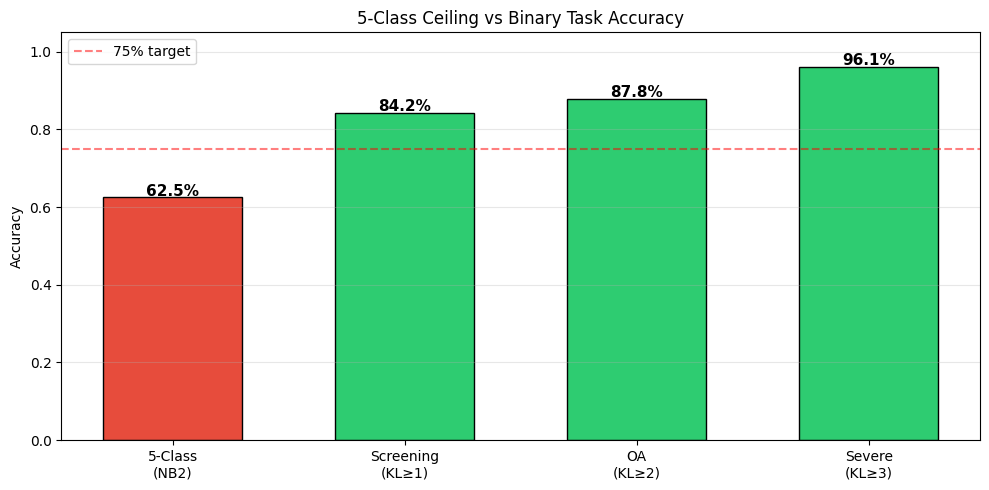

✓ nb3_comparison.png


In [10]:
# Cell 9 — 5-Class vs Binary Comparison
nb2_path = KOA_ROOT / 'NB2' / 'nb2_results.json'
if nb2_path.exists():
    with open(str(nb2_path)) as f:
        nb2 = json.load(f)
    five_class_acc = nb2['mean_accuracy']
else:
    five_class_acc = 0.68

binary_accs = {}
for task in BINARY_TASKS:
    accs = [np.mean(results[arch][task]['acc']) for arch in ARCHITECTURES]
    binary_accs[task] = max(accs)

fig, ax = plt.subplots(figsize=(10, 5))
names = ['5-Class\n(NB2)'] + [f"{t}\n(KL≥{BINARY_TASKS[t]})" for t in BINARY_TASKS]
values = [five_class_acc] + [binary_accs[t] for t in BINARY_TASKS]
colors = ['#e74c3c'] + ['#2ecc71'] * len(BINARY_TASKS)
bars = ax.bar(names, values, color=colors, edgecolor='black', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.1%}", ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Class Ceiling vs Binary Task Accuracy')
ax.set_ylim(0, 1.05)
ax.axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='75% target')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(str(NB3_OUT / 'nb3_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ nb3_comparison.png")

In [11]:
# Cell 10 — Save Results
nb3_results = {
    'tasks': {},
    'utility_threshold_shift_pp': float(shift),
}
for task in BINARY_TASKS:
    nb3_results['tasks'][task] = {}
    for arch in ARCHITECTURES:
        nb3_results['tasks'][task][arch] = {
            'acc': results[arch][task]['acc'],
            'auc': results[arch][task]['auc'],
            'sens': results[arch][task]['sens'],
            'spec': results[arch][task]['spec'],
        }

with open(str(NB3_OUT / 'nb3_results.json'), 'w') as f:
    json.dump(nb3_results, f, indent=2)

for fn in ['nb3_results.json', 'nb3_results_binary.csv', 'nb3_roc_curves.png',
           'nb3_utility.png', 'nb3_clinical_thresholds.csv', 'nb3_comparison.png']:
    print(f"  {'✓' if (NB3_OUT / fn).exists() else '✗'} {fn}")

  ✓ nb3_results.json
  ✓ nb3_results_binary.csv
  ✓ nb3_roc_curves.png
  ✓ nb3_utility.png
  ✓ nb3_clinical_thresholds.csv
  ✓ nb3_comparison.png
